# **Human Activity Recognition**

In [17]:
import pandas as pd
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt

# **1. Data Preparation**
ekstrak dataset IMU yang ditempatkan di pergelangan tangan kiri, yaitu data dengan 4 digit terakhir "1585" yang menandakan dataset ketika IMU dipasang di pergelangan tangan kiri.

In [18]:
csv_path = 'HAR-for-human-robot-interaction-in-agriculture/Human-activity-recognition-for-human-robot-interaction-in-agriculture/Raw_data'
raw_data = sorted(glob.glob(f'{csv_path}/*_1585.csv'))

df = {}
for dataset in raw_data:
    filename = Path(dataset).stem
    try:
        df[filename] = pd.read_csv(dataset)
    except Exception as e:
        print(f"error loading {dataset}: {e}")

print("all dataset with 1585 loaded successfully")



all dataset with 1585 loaded successfully


### **Split df to stand and walk**
stand (berdiri) adalah data dengan item condition = 0.0
walk (jalan) adalah data dengan item condition = 1.0

In [19]:
df_stand = {}
df_walk = {}
for item in df:
    df_stand[item] = df[item][df[item]['condition'] == 0.0]
    df_walk[item] = df[item][df[item]['condition'] == 1.0]

samakan panjang data dan lakukan data balancing

In [20]:
# Find the minimum length across all datasets
min_length = min(len(df[key]) for key in df)

# Truncate all datasets to the minimum length
for key in df:
    df[key] = df[key].iloc[:min_length]

# Also update df_stand and df_walk
for key in df_stand:
    df_stand[key] = df_stand[key].iloc[:min_length]
    
for key in df_walk:
    df_walk[key] = df_walk[key].iloc[:min_length]

print(f"All datasets normalized to length: {min_length}")

# Balance the dataset by undersampling the larger activity
# Balance at dataframe level (windows are created later in cell 9)
def undersample_activity(data_dict, target_total_rows):
    total_rows = sum(len(d) for d in data_dict.values())
    balanced = {}
    allocated = 0

    items = list(data_dict.items())
    for i, (name, d) in enumerate(items):
        if i == len(items) - 1:
            n_keep = max(0, target_total_rows - allocated)
        else:
            n_keep = int(round(len(d) * target_total_rows / total_rows))
            n_keep = min(n_keep, len(d))
            allocated += n_keep

        balanced[name] = d.iloc[:n_keep].copy()

    return balanced

walk_rows = sum(len(d) for d in df_walk.values())
stand_rows = sum(len(d) for d in df_stand.values())

print(f"Before balancing - Walk: {walk_rows} rows, Stand: {stand_rows} rows")

if walk_rows > stand_rows:
    df_walk = undersample_activity(df_walk, stand_rows)
else:
    df_stand = undersample_activity(df_stand, walk_rows)

walk_rows_balanced = sum(len(d) for d in df_walk.values())
stand_rows_balanced = sum(len(d) for d in df_stand.values())

print(f"After balancing - Walk: {walk_rows_balanced} rows, Stand: {stand_rows_balanced} rows")

All datasets normalized to length: 405
Before balancing - Walk: 30021 rows, Stand: 9284 rows
After balancing - Walk: 9284 rows, Stand: 9284 rows


# **2. Preprocessing and Customization**
apply butterworth low-pass filter, then segment the data into 2-second sliding windows with 50% overlap

In [21]:
from scipy.signal import butter, filtfilt

# Parameters
sensor_cols = ['ax_m/s/s','ay_m/s/s','az_m/s/s','gx_deg/s','gy_deg/s','gz_deg/s']
cutoff_hz = 5.0
order = 4
window_secs = 0.5
overlap = 0.5

# estimate sampling frequency from first dataset
first_df = next(iter(df.values()))
time_vals = first_df['time_s'].to_numpy(dtype=float)
dt = np.diff(time_vals)
fs = 1.0 / np.median(dt[dt > 0])
window_size = int(window_secs * fs)
stride = int(window_size * (1 - overlap))

def butter_lowpass_filter(x, cutoff, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='low', analog=False)
    return filtfilt(b, a, x, axis=0)

def segment_windows(data, win_size, stride):
    windows = []
    indices = []
    for start in range(0, len(data) - win_size + 1, stride):
        windows.append(data[start:start + win_size])
        indices.append(start)
    return np.array(windows), indices

# Apply filter and segment for both df_walk and df_stand
windows_walk = {}
indices_walk = {}
windows_stand = {}
indices_stand = {}

for name, d in df_walk.items():
    if all(col in d.columns for col in sensor_cols) and len(d) >= window_size:
        arr = d[sensor_cols].values.astype(float)
        filt = butter_lowpass_filter(arr, cutoff_hz, fs, order=order)
        d[[c + '_filt' for c in sensor_cols]] = filt
        w, idx = segment_windows(filt, window_size, stride)
        windows_walk[name] = w
        indices_walk[name] = idx

for name, d in df_stand.items():
    if all(col in d.columns for col in sensor_cols) and len(d) >= window_size:
        arr = d[sensor_cols].values.astype(float)
        filt = butter_lowpass_filter(arr, cutoff_hz, fs, order=order)
        d[[c + '_filt' for c in sensor_cols]] = filt
        w, idx = segment_windows(filt, window_size, stride)
        windows_stand[name] = w
        indices_stand[name] = idx

print(f"fs={fs:.2f}Hz, window_size={window_size} samples, stride={stride} samples")
print(f"walk: {sum(len(v) for v in windows_walk.values())} windows across {len(windows_walk)} files")
print(f"stand: {sum(len(v) for v in windows_stand.values())} windows across {len(windows_stand)} files")

fs=50.00Hz, window_size=25 samples, stride=12 samples
walk: 493 windows across 185 files
stand: 558 windows across 186 files


# **3. Feature Extraction**
extract features i.e. Mean, Standard Deviation, Signal Magnitude Area (SMA) for every window. also compute FFT to find the dominant frequency

In [22]:
from scipy.fft import fft, fftfreq

def extract_features(windows_dict, fs, sensor_cols):
    features_list = []
    
    for file_name, windows in windows_dict.items():
        for win_idx, window in enumerate(windows):
            # window shape: (window_size, 6) -> [ax, ay, az, gx, gy, gz]
            feature_dict = {
                'file': file_name,
                'window_idx': win_idx
            }
            
            # Calculate mean for each sensor
            for i, col in enumerate(sensor_cols):
                feature_dict[f'mean_{col}'] = np.mean(window[:, i])
            
            # Calculate standard deviation for each sensor
            for i, col in enumerate(sensor_cols):
                feature_dict[f'std_{col}'] = np.std(window[:, i])
            
            # Calculate Signal Magnitude Area (SMA) for accelerometer (ax, ay, az)
            accel_data = window[:, :3]  # First 3 columns are accelerometer
            sma = np.sum(np.abs(accel_data)) / len(accel_data)
            feature_dict['sma'] = sma
            
            # Compute FFT for each sensor and find dominant frequency
            freqs = fftfreq(len(window), 1/fs)
            positive_freqs_mask = freqs > 0
            
            for i, col in enumerate(sensor_cols):
                fft_vals = fft(window[:, i])
                magnitude = np.abs(fft_vals)
                
                # Get dominant frequency from positive frequencies only
                if np.sum(positive_freqs_mask) > 0:
                    dominant_idx = np.argmax(magnitude[positive_freqs_mask])
                    dominant_freq = freqs[positive_freqs_mask][dominant_idx]
                    feature_dict[f'dominant_freq_{col}'] = dominant_freq
            
            features_list.append(feature_dict)
    
    return features_list

# Extract features for walk and stand
print("Extracting features for walking activity...")
features_walk = extract_features(windows_walk, fs, sensor_cols)
features_walk_df = pd.DataFrame(features_walk)

print("Extracting features for standing activity...")
features_stand = extract_features(windows_stand, fs, sensor_cols)
features_stand_df = pd.DataFrame(features_stand)

# Add activity label
features_walk_df['activity'] = 'walk'
features_stand_df['activity'] = 'stand'

# Combine both
features_df = pd.concat([features_walk_df, features_stand_df], ignore_index=True)

print(f"\nFeature extraction completed!")
print(f"Total windows: {len(features_df)}")
print(f"  - Walk: {len(features_walk_df)} windows")
print(f"  - Stand: {len(features_stand_df)} windows")
print(f"\nFeature columns ({features_df.shape[1]}):")
print(features_df.columns.tolist())

Extracting features for walking activity...
Extracting features for standing activity...

Feature extraction completed!
Total windows: 1051
  - Walk: 493 windows
  - Stand: 558 windows

Feature columns (22):
['file', 'window_idx', 'mean_ax_m/s/s', 'mean_ay_m/s/s', 'mean_az_m/s/s', 'mean_gx_deg/s', 'mean_gy_deg/s', 'mean_gz_deg/s', 'std_ax_m/s/s', 'std_ay_m/s/s', 'std_az_m/s/s', 'std_gx_deg/s', 'std_gy_deg/s', 'std_gz_deg/s', 'sma', 'dominant_freq_ax_m/s/s', 'dominant_freq_ay_m/s/s', 'dominant_freq_az_m/s/s', 'dominant_freq_gx_deg/s', 'dominant_freq_gy_deg/s', 'dominant_freq_gz_deg/s', 'activity']


In [23]:
# Display sample features
print("Sample features (first 5 windows):")
print(features_df.head())

print("\n" + "="*80)
print("Feature Statistics by Activity")
print("="*80)

# Summary statistics for walk vs stand
summary_features = ['sma'] + [col for col in features_df.columns if col.startswith('mean_') or col.startswith('dominant_freq_')]

for activity in ['walk', 'stand']:
    print(f"\n{activity.upper()}:")
    print(features_df[features_df['activity'] == activity][summary_features].describe().round(4))


Sample features (first 5 windows):
        file  window_idx  mean_ax_m/s/s  mean_ay_m/s/s  mean_az_m/s/s  \
0  A001_1585           0       2.682742      -9.931248       3.336473   
1  A001_1585           1       2.478493     -10.788069       3.004373   
2  A011_1585           0       1.956189      -9.579383       2.333074   
3  A011_1585           1       1.813555      -9.446231       2.682300   
4  A111_1585           0       3.461217      -9.358230       1.051588   

   mean_gx_deg/s  mean_gy_deg/s  mean_gz_deg/s  std_ax_m/s/s  std_ay_m/s/s  \
0      -0.022656       0.028488       0.683959      0.431700      1.154222   
1       0.250085      -0.194753      -0.942923      0.625191      1.097228   
2      -0.024270      -0.000639       0.034960      0.056597      0.020410   
3      -0.011336      -0.076445       0.031606      0.249694      0.206613   
4      -0.007374      -0.000117       0.018203      0.015853      0.014394   

   ...  std_gy_deg/s  std_gz_deg/s        sma  dominant_f

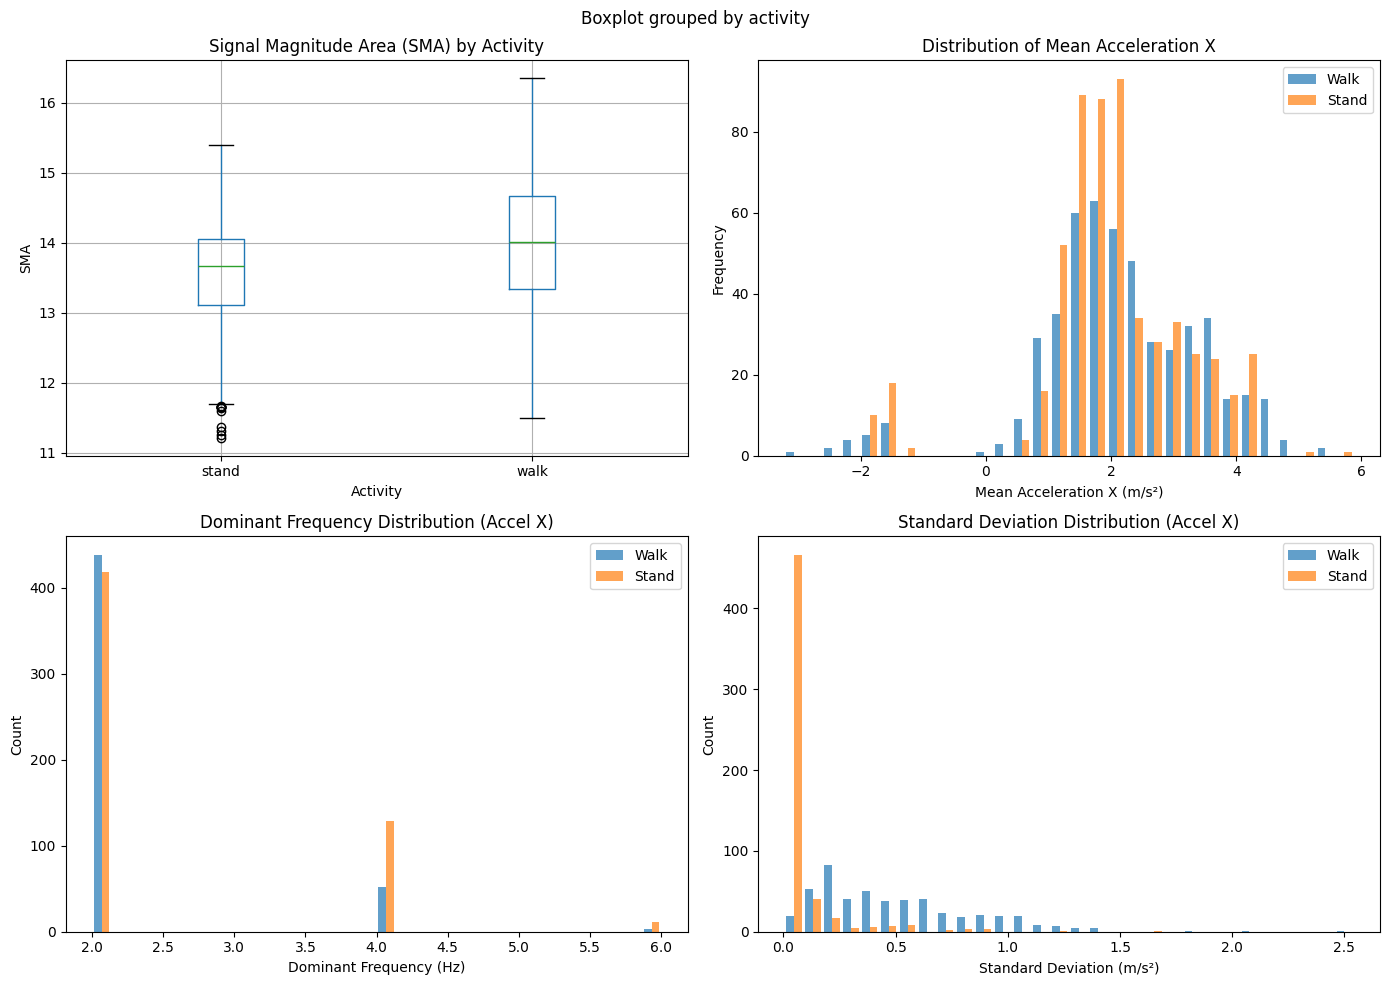

Feature visualization complete!


In [24]:
# Visualization of key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. SMA comparison
ax = axes[0, 0]
features_df.boxplot(column='sma', by='activity', ax=ax)
ax.set_title('Signal Magnitude Area (SMA) by Activity')
ax.set_xlabel('Activity')
ax.set_ylabel('SMA')

# 2. Mean acceleration magnitude
ax = axes[0, 1]
walk_means = features_df[features_df['activity'] == 'walk']['mean_ax_m/s/s'].values
stand_means = features_df[features_df['activity'] == 'stand']['mean_ax_m/s/s'].values
ax.hist([walk_means, stand_means], label=['Walk', 'Stand'], bins=30, alpha=0.7)
ax.set_xlabel('Mean Acceleration X (m/s²)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Mean Acceleration X')
ax.legend()

# 3. Dominant frequency for accelerometer X
ax = axes[1, 0]
walk_freqs = features_df[features_df['activity'] == 'walk']['dominant_freq_ax_m/s/s'].values
stand_freqs = features_df[features_df['activity'] == 'stand']['dominant_freq_ax_m/s/s'].values
ax.hist([walk_freqs, stand_freqs], label=['Walk', 'Stand'], bins=30, alpha=0.7)
ax.set_xlabel('Dominant Frequency (Hz)')
ax.set_ylabel('Count')
ax.set_title('Dominant Frequency Distribution (Accel X)')
ax.legend()

# 4. STD deviation comparison
ax = axes[1, 1]
walk_stds = features_df[features_df['activity'] == 'walk']['std_ax_m/s/s'].values
stand_stds = features_df[features_df['activity'] == 'stand']['std_ax_m/s/s'].values
ax.hist([walk_stds, stand_stds], label=['Walk', 'Stand'], bins=30, alpha=0.7)
ax.set_xlabel('Standard Deviation (m/s²)')
ax.set_ylabel('Count')
ax.set_title('Standard Deviation Distribution (Accel X)')
ax.legend()

plt.tight_layout()
plt.show()

print("Feature visualization complete!")

In [25]:
# Save features to CSV for further analysis
output_path = 'extracted_features.csv'
features_df.to_csv(output_path, index=False)
print(f"Features saved to: {output_path}")
print(f"Total features extracted: {features_df.shape[0]} windows")
print(f"Total feature columns: {features_df.shape[1]}")
print("\nFeature summary:")
print(f"  - Mean values: {len(sensor_cols)} sensors × 2 (mean per sensor)")
print(f"  - Std deviations: {len(sensor_cols)} sensors")
print(f"  - Signal Magnitude Area (SMA): 1 (accelerometer only)")
print(f"  - Dominant frequencies: {len(sensor_cols)} sensors")
print(f"  - Activity label: 1")

Features saved to: extracted_features.csv
Total features extracted: 1051 windows
Total feature columns: 22

Feature summary:
  - Mean values: 6 sensors × 2 (mean per sensor)
  - Std deviations: 6 sensors
  - Signal Magnitude Area (SMA): 1 (accelerometer only)
  - Dominant frequencies: 6 sensors
  - Activity label: 1


# **4. Data Splitting and Training**
* Splitting the datasets into 3 groups: 70% training, 15% validation, 15% testing
* kernel = rbf (radial basis function) yang merupakan kernel non linear -> memetakan data ke ruang berdimensi lebih tinggi secara implisit lalu mencari separator di sana (kernel trick), sehingga boundary di feature space asli menjadi melengkung/non-linear.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prepare data
X = features_df.drop(['file', 'window_idx', 'activity'], axis=1)
y = (features_df['activity'] == 'walk').astype(int)  # 1 for walk, 0 for stand

# Step 1: Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Step 2: Split temp (30%) into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Step 3: Normalize features (fit scaler on TRAINING data only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Step 4: Train SVM model for training and validation dataset only
from sklearn.metrics import accuracy_score

C_list = [0.1, 1, 10, 100]
gamma_list = [0.001, 0.01, 0.1, 1]

best_acc = 0
best_model = None

for C in C_list:
    for gamma in gamma_list:

        model = SVC(
            kernel='rbf',
            C=C,
            gamma=gamma,
            random_state=42
        )

        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_val_scaled)
        acc = accuracy_score(y_val, pred)

        print(f"C={C}, gamma={gamma}, acc={acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_model = model

print(best_acc)

# Step 5: Evaluate
# train_pred = svm_model.predict(X_train_scaled)
# val_pred = svm_model.predict(X_val_scaled)

train_pred = best_model.predict(X_train_scaled)
val_pred = best_model.predict(X_val_scaled)


print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("\nTest Classification Report:")


# Step 5 : testing -- uncomment for test
X_test_scaled = scaler.transform(X_test)
test_pred = best_model.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred, target_names=['Stand', 'Walk']))

C=0.1, gamma=0.001, acc=0.5570
C=0.1, gamma=0.01, acc=0.8481
C=0.1, gamma=0.1, acc=0.8544
C=0.1, gamma=1, acc=0.5316
C=1, gamma=0.001, acc=0.8481
C=1, gamma=0.01, acc=0.8861
C=1, gamma=0.1, acc=0.8861
C=1, gamma=1, acc=0.7532
C=10, gamma=0.001, acc=0.8671
C=10, gamma=0.01, acc=0.8797
C=10, gamma=0.1, acc=0.8671
C=10, gamma=1, acc=0.7468
C=100, gamma=0.001, acc=0.9051
C=100, gamma=0.01, acc=0.8734
C=100, gamma=0.1, acc=0.8797
C=100, gamma=1, acc=0.7405
0.9050632911392406
Training Accuracy: 0.9333333333333333
Validation Accuracy: 0.9050632911392406

Test Classification Report:
Test Accuracy: 0.9050632911392406
              precision    recall  f1-score   support

       Stand       0.88      0.95      0.91        84
        Walk       0.94      0.85      0.89        74

    accuracy                           0.91       158
   macro avg       0.91      0.90      0.90       158
weighted avg       0.91      0.91      0.90       158



# **5. Performance Evaluation and Visualization**

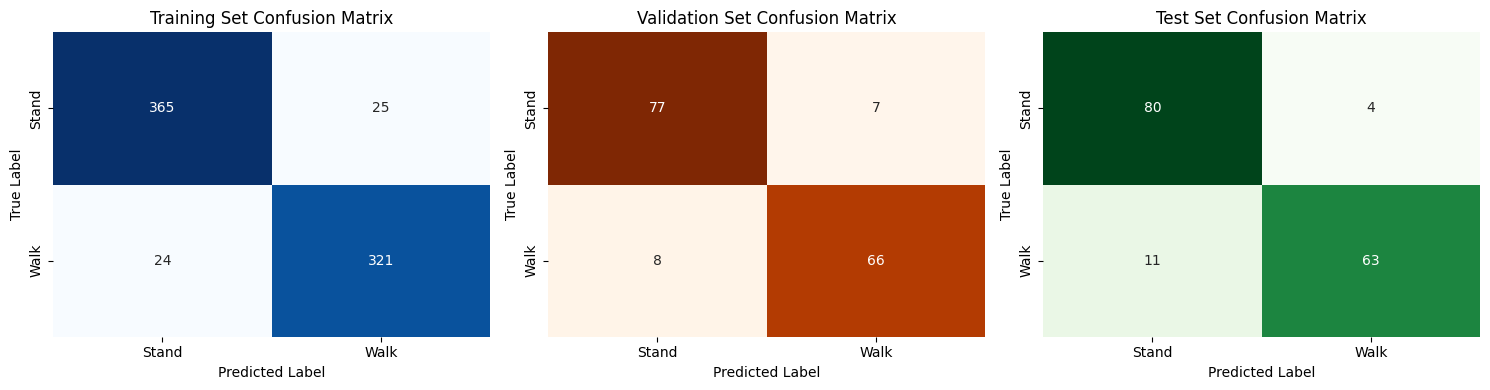

CONFUSION MATRIX ANALYSIS

TRAINING SET:
  True Negatives: 365, False Positives: 25
  False Negatives: 24, True Positives: 321
  Sensitivity (Recall): 0.9304
  Specificity: 0.9359
  Precision: 0.9277

VALIDATION SET:
  True Negatives: 77, False Positives: 7
  False Negatives: 8, True Positives: 66
  Sensitivity (Recall): 0.8919
  Specificity: 0.9167
  Precision: 0.9041

TRAINING SET:
  True Negatives: 365, False Positives: 25
  False Negatives: 24, True Positives: 321
  Sensitivity (Recall): 0.9304
  Specificity: 0.9359
  Precision: 0.9277

VALIDATION SET:
  True Negatives: 77, False Positives: 7
  False Negatives: 8, True Positives: 66
  Sensitivity (Recall): 0.8919
  Specificity: 0.9167
  Precision: 0.9041

TEST SET:
  True Negatives: 80, False Positives: 4
  False Negatives: 11, True Positives: 63
  Sensitivity (Recall): 0.8514
  Specificity: 0.9524
  Precision: 0.9403


In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score
from sklearn.metrics import roc_auc_score, precision_score, recall_score


# Create confusion matrices for all three sets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training set confusion matrix
cm_train = confusion_matrix(y_train, train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Training Set Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['Stand', 'Walk'])
axes[0].set_yticklabels(['Stand', 'Walk'])

# Validation set confusion matrix
cm_val = confusion_matrix(y_val, val_pred)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
axes[1].set_title('Validation Set Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_xticklabels(['Stand', 'Walk'])
axes[1].set_yticklabels(['Stand', 'Walk'])

# Test set confusion matrix -- uncomment for test
cm_test = confusion_matrix(y_test, test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[2], cbar=False)
axes[2].set_title('Test Set Confusion Matrix')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')
axes[2].set_xticklabels(['Stand', 'Walk'])
axes[2].set_yticklabels(['Stand', 'Walk'])

plt.tight_layout()
plt.show()

# Print detailed metrics for each set
print("=" * 60)
print("CONFUSION MATRIX ANALYSIS")
print("=" * 60)

# exdlude testing set
for name, cm, y_true, y_pred in [('Training', cm_train, y_train, train_pred), 
                                   ('Validation', cm_val, y_val, val_pred)]:
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name.upper()} SET:")
    print(f"  True Negatives: {tn}, False Positives: {fp}")
    print(f"  False Negatives: {fn}, True Positives: {tp}")
    print(f"  Sensitivity (Recall): {tp / (tp + fn):.4f}")
    print(f"  Specificity: {tn / (tn + fp):.4f}")
    print(f"  Precision: {tp / (tp + fp):.4f}")

# include testing set
for name, cm, y_true, y_pred in [('Training', cm_train, y_train, train_pred), 
                                   ('Validation', cm_val, y_val, val_pred), 
                                   ('Test', cm_test, y_test, test_pred)]:
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{name.upper()} SET:")
    print(f"  True Negatives: {tn}, False Positives: {fp}")
    print(f"  False Negatives: {fn}, True Positives: {tp}")
    print(f"  Sensitivity (Recall): {tp / (tp + fn):.4f}")
    print(f"  Specificity: {tn / (tn + fp):.4f}")
    print(f"  Precision: {tp / (tp + fp):.4f}")

In [28]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# import numpy as np

# # Reduce to 2D
# pca = PCA(n_components=2)

# X_train_2d = pca.fit_transform(X_train_scaled)

# # Train SVM in PCA space
# svm_2d = SVC(kernel='rbf', C=100, gamma='scale')
# svm_2d.fit(X_train_2d, y_train)

# # meshgrid
# x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
# y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

# xx, yy = np.meshgrid(
#     np.linspace(x_min, x_max, 300),
#     np.linspace(y_min, y_max, 300)
# )

# Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
# Z = Z.reshape(xx.shape)

# # Plot
# plt.figure(figsize=(8,6))

# plt.contourf(xx, yy, Z, alpha=0.3)

# scatter = plt.scatter(
#     X_train_2d[:,0],
#     X_train_2d[:,1],
#     c=y_train,
# )

# plt.xlabel("PCA Component 1")
# plt.ylabel("PCA Component 2")
# plt.title("SVM Decision Boundary (PCA Projection)")
# plt.show()